In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from fraud_detector import FraudDetector

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
detector = FraudDetector('data/fraud.csv')
df = detector.load_data()

Data loaded successfully!
Shape: (7000, 13)

First 5 rows:
   transaction_amount  hour_of_day  is_weekend  num_items  customer_age  \
0          161.363691          3.0         0.0        2.0     18.000000   
1          116.202851          1.0         1.0        4.0     26.285818   
2            1.000000          2.0         0.0        5.0     18.000000   
3           48.780618          2.0         0.0        3.0     44.471190   
4                 NaN          3.0         0.0        4.0     38.733609   

   prev_transactions  distance_from_home  device_type  network_quality  \
0                2.0           26.539742          1.0        48.403937   
1                2.0           50.714402          NaN        76.144979   
2                NaN            9.467935          0.0        67.600316   
3                NaN           41.077068          0.0        94.825526   
4                8.0                 NaN          2.0       100.000000   

   is_first_transaction  store_type  velocity

In [3]:
detector.explore_data()


Missing Values
transaction_amount       560
hour_of_day              350
is_weekend               140
num_items                210
customer_age             840
prev_transactions        490
distance_from_home       700
device_type              280
network_quality          630
is_first_transaction     210
store_type               140
velocity_score          1050
is_fraud                   0
dtype: int64

Data Types
transaction_amount      float64
hour_of_day             float64
is_weekend              float64
num_items               float64
customer_age            float64
prev_transactions       float64
distance_from_home      float64
device_type             float64
network_quality         float64
is_first_transaction    float64
store_type              float64
velocity_score          float64
is_fraud                  int64
dtype: object

Basic Statistics
       transaction_amount  hour_of_day   is_weekend    num_items  \
count         6440.000000  6650.000000  6860.000000  6790.000000  

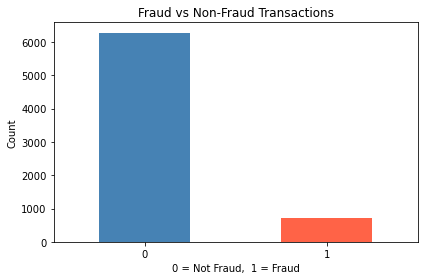

In [4]:
df = detector.df

plt.figure(figsize=(6, 4))
df['is_fraud'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('0 = Not Fraud,  1 = Fraud')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plots/class_imbalance.png')
plt.show()

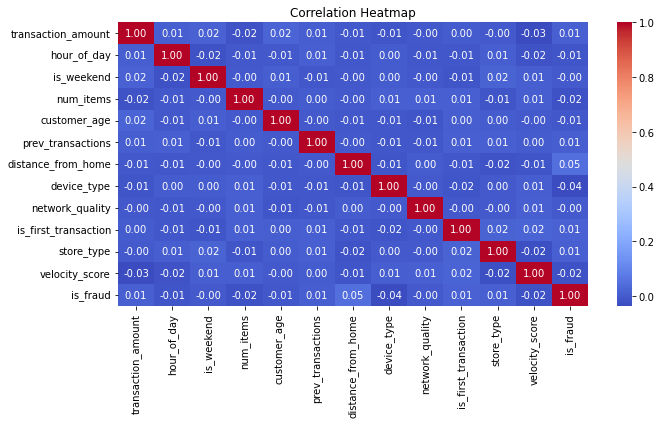

In [5]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png')
plt.show()

In [6]:
detector.preprocess(target_column='is_fraud')


Class distribution before SMOTE:
0    2737
1     336
Name: is_fraud, dtype: int64

Class distribution after SMOTE:
0    2737
1    2737
Name: is_fraud, dtype: int64

Training samples: 4379
Testing samples:  1095


c:\Users\spectre\anaconda3\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [7]:
detector.train()


Training Logistic Regression...
Done!

Training Random Forest...
Done!


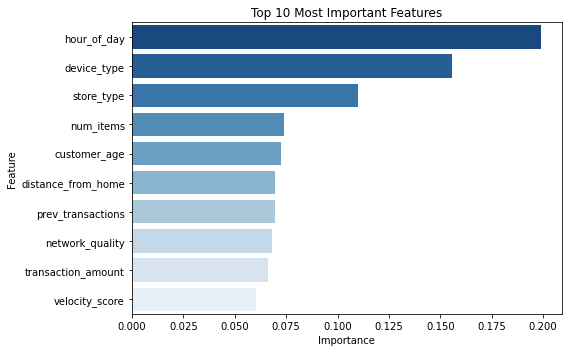

Feature importance chart saved to plots/


In [8]:
detector.plot_feature_importance()